In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor # We are upgrading to a Tree-Based Imputer!

# 1. LOADING THE DATA
df = pd.read_csv('../data/credit_risk_dataset.csv')

# 2. CLEANING THE DATA (Outliers & Basic Blanks)
df = df[df['person_age'] <= 90]
df['person_emp_length'] = df['person_emp_length'].fillna(0)
df = df[df['person_emp_length'] <= df['person_age']]

In [2]:
# 1. Create basic flags
df['employment_status'] = np.where(df['person_emp_length'] > 0, 'EMPLOYED', 'UNEMPLOYED')
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

# 2. Drop loan_grade (Leakage) and person_emp_length (Replaced)
df = df.drop(['loan_grade', 'person_emp_length'], axis=1)

# 3. Create the Dummies
df_final = pd.get_dummies(
    df, 
    columns=['person_home_ownership', 'loan_intent', 'employment_status'], 
    drop_first=False, 
    dtype=int
)

In [3]:
# 1. Isolate the people who actually have an interest rate
known_rates = df_final[df_final['loan_int_rate'].notnull()]

# 2. Define the columns the AI is ALLOWED to look at 
# (Everything in the dataset EXCEPT the target and the answer key)
allowed_features = known_rates.drop(['loan_status', 'loan_int_rate'], axis=1).columns

# 3. Run the automatic correlation scanner
correlations = known_rates[allowed_features.tolist() + ['loan_int_rate']].corr()['loan_int_rate'].sort_values(ascending=False)

print("Top 5 Positive Correlations:\n", correlations.head(6)[1:]) # [1:] skips itself (1.0)
print("\nTop 5 Negative Correlations:\n", correlations.tail(5))

Top 5 Positive Correlations:
 cb_person_default_on_file      0.501052
loan_amnt                      0.146803
person_home_ownership_RENT     0.138344
loan_percent_income            0.120218
loan_intent_HOMEIMPROVEMENT    0.020749
Name: loan_int_rate, dtype: float64

Top 5 Negative Correlations:
 loan_intent_DEBTCONSOLIDATION    -0.003801
loan_intent_VENTURE              -0.008936
loan_intent_EDUCATION            -0.009419
person_home_ownership_OWN        -0.013682
person_home_ownership_MORTGAGE   -0.135058
Name: loan_int_rate, dtype: float64


In [4]:
from xgboost import XGBRegressor
# 1. Define the missing rates bucket
missing_rates = df_final[df_final['loan_int_rate'].isnull()]


# 2. Isolate the allowed features and the target rate
X_known = known_rates[allowed_features]
y_known = known_rates['loan_int_rate']

# 3. Train the Advanced "Mini-Brain" (XGBRegressor instead of Linear Regression)
xgb_imputer = XGBRegressor(random_state=42)
xgb_imputer.fit(X_known, y_known)

# 4. Ask the AI to predict the missing rates
X_missing = missing_rates[allowed_features]
predicted_rates = xgb_imputer.predict(X_missing)

# 5. Inject predictions back into the main database
df_final.loc[df_final['loan_int_rate'].isnull(), 'loan_int_rate'] = predicted_rates



# df_final.to_csv('../data/credit_risk_dataset_imputed.csv', index=False)

In [5]:
df_final.head()

,person_age,person_income,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,employment_status_EMPLOYED,employment_status_UNEMPLOYED
1,21,9600,1000,11.14,0,0.10,0,2,0,0,1,0,0,1,0,0,0,0,1,0
2,25,9600,5500,12.87,1,0.57,0,3,1,0,0,0,0,0,0,1,0,0,1,0
3,23,65500,35000,15.23,1,0.53,0,2,0,0,0,1,0,0,0,1,0,0,1,0
4,24,54400,35000,14.27,1,0.55,1,4,0,0,0,1,0,0,0,1,0,0,1,0
5,21,9900,2500,7.14,1,0.25,0,2,0,0,1,0,0,0,0,0,0,1,1,0


In [6]:
# Calculate correlations with the target variable 'loan_status'

correlations = df_final.corr()['loan_status'].sort_values(ascending=False)

# Grab the top 5 strongest correlations
top_danger_signs = correlations[1:] 

print("RAW DATABASE OUTPUT (Top 5 Correlation Scores):")
print("-" * 50)
print(top_danger_signs)

RAW DATABASE OUTPUT (Top 5 Correlation Scores):
--------------------------------------------------
loan_percent_income               0.379272
loan_int_rate                     0.329649
person_home_ownership_RENT        0.238437
cb_person_default_on_file         0.178995
loan_amnt                         0.105233
loan_intent_DEBTCONSOLIDATION     0.071533
employment_status_UNEMPLOYED      0.069712
loan_intent_MEDICAL               0.056620
loan_intent_HOMEIMPROVEMENT       0.036591
person_home_ownership_OTHER       0.012541
cb_person_cred_hist_length       -0.015394
person_age                       -0.020549
loan_intent_PERSONAL             -0.021236
loan_intent_EDUCATION            -0.055307
employment_status_EMPLOYED       -0.069712
loan_intent_VENTURE              -0.078197
person_home_ownership_OWN        -0.101986
person_income                    -0.168500
person_home_ownership_MORTGAGE   -0.187623
Name: loan_status, dtype: float64


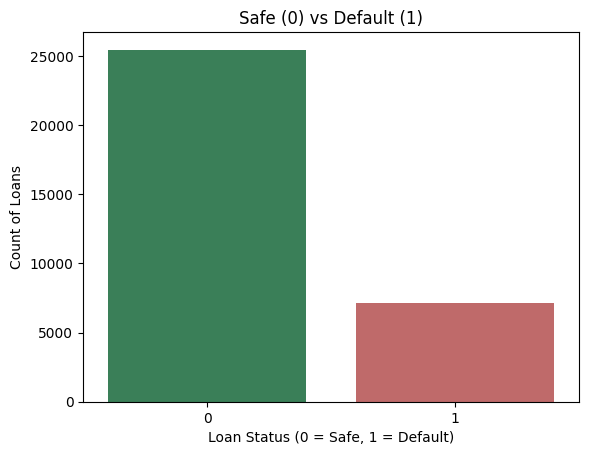

In [7]:
# Basic Data Exploration
# 1. Simple count of good vs bad loans
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df_final, x='loan_status', hue='loan_status', palette=['seagreen', 'indianred'], legend=False)
plt.title("Safe (0) vs Default (1)")
plt.ylabel("Count of Loans")  
plt.xlabel("Loan Status (0 = Safe, 1 = Default)") 

plt.show()

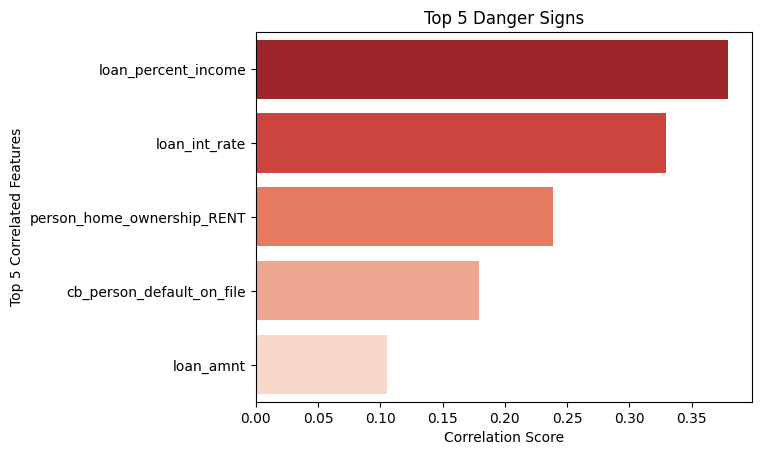

In [8]:
# 2. Plot the top 5 ALREADY calculated correlations
top_5 = correlations[1:6] 

sns.barplot(x=top_5.values, y=top_5.index, hue=top_5.index, palette='Reds_r', legend=False)
plt.title("Top 5 Danger Signs")

plt.ylabel("Top 5 Correlated Features") 
plt.xlabel("Correlation Score")

plt.show()

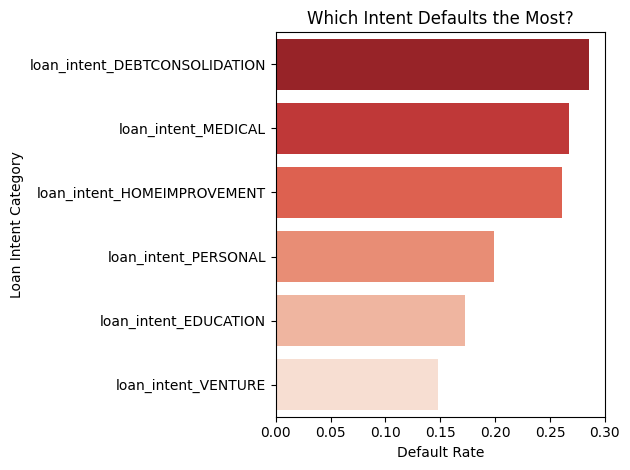

In [9]:
intent_cols = [c for c in df_final.columns if 'intent' in c.lower()]
rates = {c: df_final[df_final[c]==1]['loan_status'].mean() for c in intent_cols}

# Convert to Pandas Series and sort descending
sorted_rates = pd.Series(rates).sort_values(ascending=False)


sns.barplot(x=sorted_rates.values, y=sorted_rates.index, hue=sorted_rates.index, palette='Reds_r', legend=False)

plt.title("Which Intent Defaults the Most?")
plt.xlabel("Default Rate")
plt.ylabel("Loan Intent Category") 

plt.tight_layout()
plt.show()

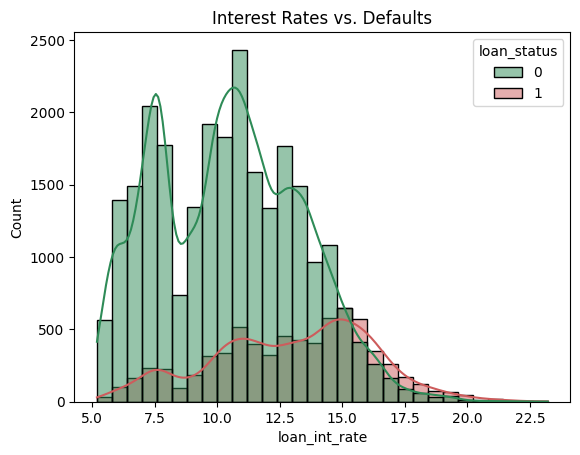

In [10]:
sns.histplot(data=df_final, x='loan_int_rate', hue='loan_status', legend = True , palette=['seagreen', 'indianred'], bins=30, kde=True)

plt.title("Interest Rates vs. Defaults")
plt.show()

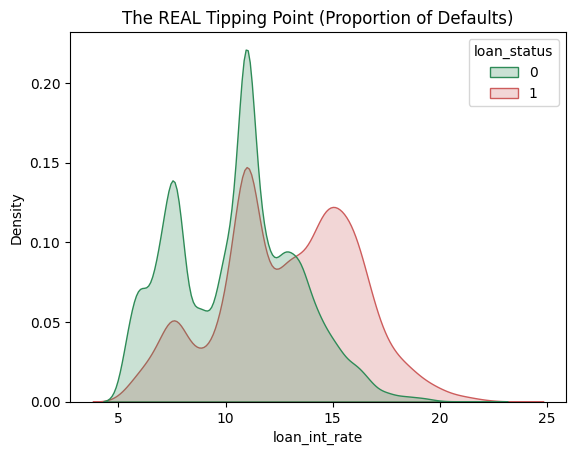

In [8]:
# Using 'kdeplot' with common_norm=False shows us the proportion instead of raw volume
sns.kdeplot(data=df_final, x='loan_int_rate', hue='loan_status', fill=True, common_norm=False, palette=['seagreen', 'indianred'])

plt.title("The REAL Tipping Point (Proportion of Defaults)")
plt.show()

In [9]:
# Income VS Defaults
# sns.boxplot(data=df_final, x='loan_status', y='person_income')
# plt.title("Income vs. Defaults")
# plt.xlabel("Loan Status")
# plt.ylabel("Person Income")
# plt.show()



In [11]:
# 1. Create age brackets using pd.cut
bins = [20, 30, 40, 50, 60, 70, 100]
labels = ['20-29', '30-39', '40-49', '50-59', '60-69', '70+']

# right=False means the bins are [20, 30), so 30 goes into the next bin
df_final['age_bracket'] = pd.cut(df_final['person_age'], bins=bins, labels=labels, right=False)

# 2. Calculate total borrowers, total defaults, and the default rate
# Move `observed=False` into the groupby() function!
summary = df_final.groupby('age_bracket', observed=False).agg(
    total_borrowers=('loan_status', 'count'),
    total_defaults=('loan_status', 'sum'),
    default_rate=('loan_status', 'mean')
).reset_index()

# 3. Format the output to look clean
summary['default_rate_percentage'] = (summary['default_rate'] * 100).round(2).astype(str) + '%'
print(summary)

  age_bracket  total_borrowers  total_defaults  default_rate  \
0       20-29            23506            5252      0.223432   
1       30-39             7308            1479      0.202381   
2       40-49             1425             291      0.204211   
3       50-59              255              61      0.239216   
4       60-69               65              22      0.338462   
5         70+               14               2      0.142857   

  default_rate_percentage  
0                  22.34%  
1                  20.24%  
2                  20.42%  
3                  23.92%  
4                  33.85%  
5                  14.29%  


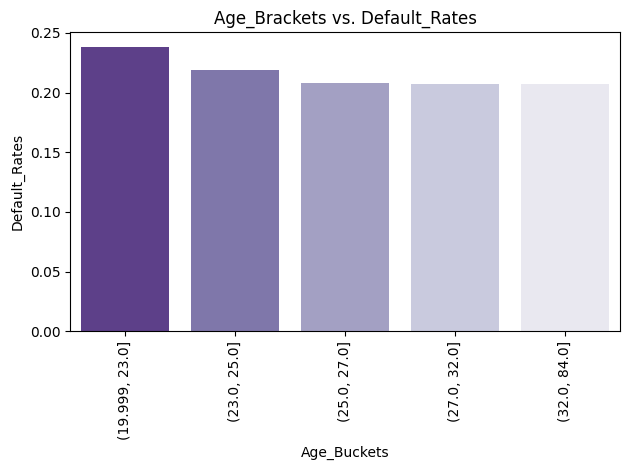

In [12]:
# testing the same for age as well to see it  draws out something
df_final['age_bracket'] = pd.qcut(df_final['person_age'], q = 5)
age_rates = df_final.groupby('age_bracket', observed = False)['loan_status'].mean()

sns.barplot(x = age_rates.index.astype(str), y = age_rates.values, 
            hue = age_rates.index.astype(str), palette = 'Purples_r', legend = False)
plt.title("Age_Brackets vs. Default_Rates")
plt.xlabel("Age_Buckets")
plt.ylabel("Default_Rates")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

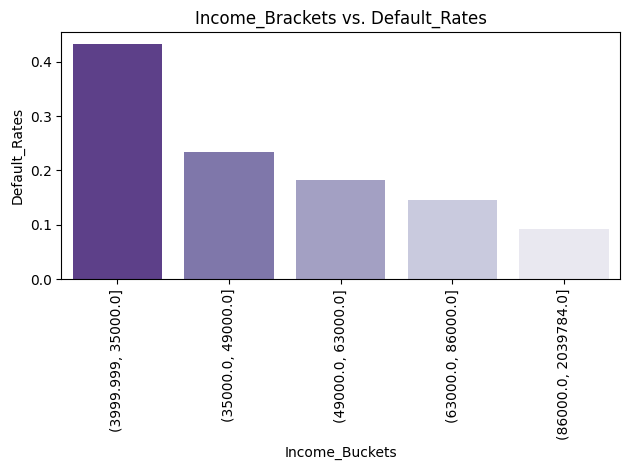

In [13]:
#DOING THE SAME with income vs default rate
df_final['income_bracket'] = pd.qcut(df_final['person_income'], q = 5)
income_rates = df_final.groupby('income_bracket', observed = False)['loan_status'].mean()

sns.barplot(x = income_rates.index.astype(str), y = income_rates.values, 
            hue = income_rates.index.astype(str), palette = 'Purples_r', legend = False)
plt.title("Income_Brackets vs. Default_Rates")
plt.xlabel("Income_Buckets")
plt.ylabel("Default_Rates")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


In [14]:
from sklearn.model_selection import train_test_split

# 1. Drop the target AND the text-based EDA buckets
X = df_final.drop(['loan_status', 'age_bracket', 'income_bracket'], axis=1)
y = df_final['loan_status']

# 2. Lock 20% of the data in the "Vault"
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} customers.")
print(f"Testing on {len(X_test)} unseen customers.")

Training on 26058 customers.
Testing on 6515 unseen customers.


In [15]:
# 1. Count the Safes (0) and Defaults (1)
safe_count = y_train.value_counts()[0]
default_count = y_train.value_counts()[1]

# 2. Calculate the ratio (Safes divided by Defaults)
imbalance_ratio = safe_count / default_count

print(f"Imbalance Ratio (scale_pos_weight): {imbalance_ratio:.2f}")

Imbalance Ratio (scale_pos_weight): 3.59


In [16]:
from xgboost import XGBClassifier

# 1. Set the rules
xgb_model = XGBClassifier(scale_pos_weight=imbalance_ratio, random_state=50)

# 2. Let it study (This is where it learns the patterns)
xgb_model.fit(X_train, y_train)

print("Training Complete!")

Training Complete!


In [17]:
# 1. Ask for probabilities, not just raw 0s and 1s
# [:, 1] grabs the probability that the customer is a Default
y_probabilities = xgb_model.predict_proba(X_test)[:, 1]

print("Probabilities successfully generated!")

Probabilities successfully generated!


In [18]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# 1. Calculate scores for every possible threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_probabilities)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls)

# 2. Find the absolute best one
optimal_idx = np.argmax(f1_scores)
best_threshold = thresholds[optimal_idx]
best_f1 = f1_scores[optimal_idx]

print(f"The mathematically perfect threshold is: {best_threshold:.3f}")
print(f"Maximum possible F1-Score: {best_f1:.3f}")

The mathematically perfect threshold is: 0.643
Maximum possible F1-Score: 0.804


In [19]:
from sklearn.metrics import classification_report, confusion_matrix

# 1. Apply the custom threshold to make the final Yes/No decision
optimized_predictions = (y_probabilities >= best_threshold).astype(int)

# 2. Print the final results
print(f"--- OPTIMIZED REPORT CARD (Threshold: {best_threshold:.3f}) ---")
print(confusion_matrix(y_test, optimized_predictions))
print("\n", classification_report(y_test, optimized_predictions))

--- OPTIMIZED REPORT CARD (Threshold: 0.643) ---
[[4933  151]
 [ 367 1064]]

               precision    recall  f1-score   support

           0       0.93      0.97      0.95      5084
           1       0.88      0.74      0.80      1431

    accuracy                           0.92      6515
   macro avg       0.90      0.86      0.88      6515
weighted avg       0.92      0.92      0.92      6515



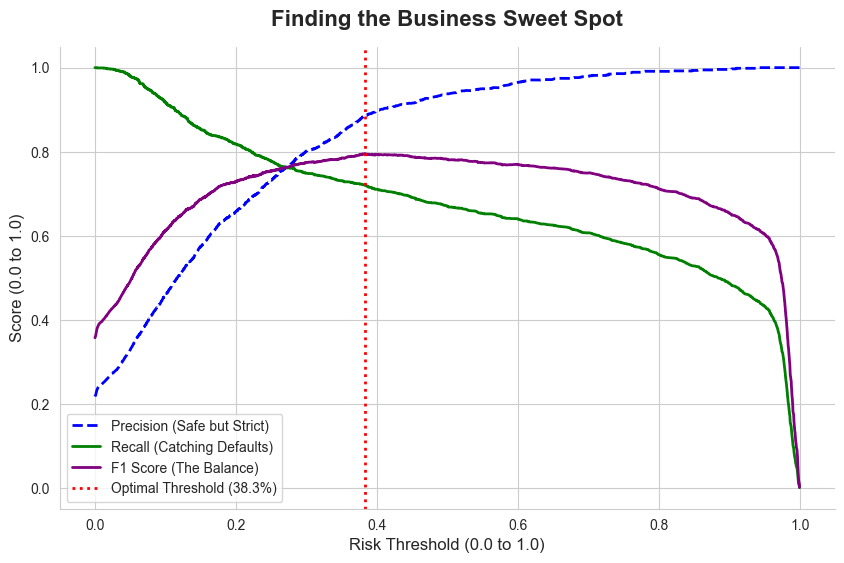

In [22]:
# CELL 3: PLOTTING THE TRADE-OFF
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Draw the lines
plt.plot(thresholds, precisions[:-1], 'b--', label='Precision (Safe but Strict)', linewidth=2)
plt.plot(thresholds, recalls[:-1], 'g-', label='Recall (Catching Defaults)', linewidth=2)
plt.plot(thresholds, f1_scores, 'purple', label='F1 Score (The Balance)', linewidth=2)

# Draw a red line exactly where the winning threshold is
plt.axvline(x=optimal_threshold, color='red', linestyle=':', linewidth=2, 
            label=f'Optimal Threshold ({optimal_threshold*100:.1f}%)')

plt.title('Finding the Business Sweet Spot', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Risk Threshold (0.0 to 1.0)', fontsize=12)
plt.ylabel('Score (0.0 to 1.0)', fontsize=12)
plt.legend(loc='lower left', fontsize=10)

sns.despine()
plt.show()

In [ ]:
# TO DO : Connect XGBoost predict_proba to Ollama prompt
